# SARS-CoV-2 Variant Classification and Prediction Stability Analysis

**Dissertation title:** *Stability of SARS-CoV-2 Variant Classification Using Supervised Machine Learning Methods and Natural Vector-like Feature Representations*

This notebook contains the computational analysis supporting the dissertation. It prepares pre-extracted SARS-CoV-2 genomic feature representations, compares supervised machine learning classifiers, evaluates the selected model on a fixed test set, and assesses prediction stability using bootstrap resampling.

The notebook is intended for supervisor, examiner and researcher review. It should be run from top to bottom in order.

## Notebook overview

The workflow in this notebook is:

1. configure the analysis environment and output folders;
2. locate and load the pre-extracted feature files;
3. check alignment, target labels, metadata and predictor columns;
4. apply the rare-class rule and create one fixed development/test split;
5. compare feature representation and classifier combinations using repeated stratified cross-validation;
6. select three feature representations and one classifier using development-set evidence;
7. evaluate final test set performance;
8. run bootstrap prediction stability analysis;
9. export numerical outputs, figures and reproducibility information.

The notebook preserves the same analytical decisions used for the dissertation, including the target column, random seed, split design, models, evaluation metrics and bootstrap settings.

## 1. Environment and library setup

This section imports the required Python packages and defines the main configuration values. The random state, cross-validation design, rare-class threshold and bootstrap settings are defined here so that the analysis settings are easy to check.

In [1]:
from pathlib import Path
import os
import json
import time
import shutil
import subprocess
import platform
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from joblib import dump, load
from IPython.display import display

from sklearn.base import clone
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    log_loss,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils import check_random_state

warnings.filterwarnings("default")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Main directories
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
RAW_ARCHIVE_DIR = DATA_DIR / "raw_archive"
EXTRACTED_DIR = DATA_DIR / "Features_extracted"
OUTPUT_DIR = PROJECT_DIR / "outputs_revised"
METRICS_DIR = OUTPUT_DIR / "metrics"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
BOOTSTRAP_DIR = OUTPUT_DIR / "bootstrap"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

for folder in [DATA_DIR, RAW_ARCHIVE_DIR, EXTRACTED_DIR, OUTPUT_DIR, METRICS_DIR, FIGURES_DIR, MODELS_DIR, BOOTSTRAP_DIR, CHECKPOINT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Core dataset columns
TARGET_COL = "scorpio_lineage_min"
ID_COL = "taxon"
FEATURE_START_AFTER_COL = "timedelta_days"

# Main analysis settings
TEST_SIZE = 0.20
CV_N_SPLITS = 5
CV_N_REPEATS = 2
MIN_CLASS_SIZE_MAIN = 30
RARE_CLASS_STRATEGY = "exclude_below_threshold"  # options: retain_all, exclude_below_threshold


# Long-running bootstrap setting. Keep this at 200 or more for the final analysis.
B_BOOTSTRAP = 200
BOOTSTRAP_CHECKPOINT_EVERY = 10
USE_STRATIFIED_BOOTSTRAP = True


# If computational resources are limited, these can be changed for testing only.
QUICK_TEST_MODE = False
QUICK_TEST_MAX_ROWS = 5000


print("Configuration loaded")
print(f"Project directory: {PROJECT_DIR}")
print(f"Outputs will be saved to: {OUTPUT_DIR}")
print(f"Bootstrap repetitions requested: {B_BOOTSTRAP}")


/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration loaded
Project directory: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis
Outputs will be saved to: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/outputs_revised
Bootstrap repetitions requested: 200


## 2. File paths and optional archive extraction

The notebook expects the extracted feature files to be available in `data/Features_extracted/`. If the feature files are still stored as a split 7-Zip archive, the archive should be placed in `data/raw_archive/`.

The extraction step is not part of the statistical analysis. It is included only to make the workflow easier to reproduce when starting from the archived feature files.

In [2]:
FIRST_ARCHIVE_PART = RAW_ARCHIVE_DIR / "Features.7z.001"


def find_7z_executable():
    """Find a 7-Zip executable on the system."""
    for exe in ["7z", "7zz", "7za"]:
        found = shutil.which(exe)
        if found is not None:
            return found
    return None


def extract_split_7z_flat(first_part=FIRST_ARCHIVE_PART, output_dir=EXTRACTED_DIR, clean_output=False):
    """Extract a split 7-Zip archive directly into output_dir without preserving internal folders."""
    first_part = Path(first_part)
    output_dir = Path(output_dir)

    if not first_part.exists():
        print(f"Archive not found: {first_part}")
        print("If the CSV files are already extracted, this is not a problem.")
        return False

    exe = find_7z_executable()
    if exe is None:
        print("7-Zip executable not found.")
        print("On Mac, install with: brew install p7zip")
        return False

    if clean_output and output_dir.exists():
        shutil.rmtree(output_dir)

    output_dir.mkdir(parents=True, exist_ok=True)
    cmd = [exe, "e", str(first_part), f"-o{output_dir}", "-y"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
    print("Extraction complete.")
    return True


# Run extraction only when the split archive is present.
if FIRST_ARCHIVE_PART.exists():
    extract_split_7z_flat(clean_output=False)
else:
    print(f"Archive not found: {FIRST_ARCHIVE_PART}")
    print("Continuing without extraction because extracted feature files may already be available.")


Running: /opt/homebrew/bin/7z e /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/raw_archive/Features.7z.001 -o/Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/Features_extracted -y

7-Zip [64] 17.05 : Copyright (c) 1999-2021 Igor Pavlov : 2017-08-28
p7zip Version 17.05 (locale=utf8,Utf16=on,HugeFiles=on,64 bits,12 CPUs LE)

Scanning the drive for archives:
1 file, 26214400 bytes (25 MiB)

Extracting archive: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/raw_archive/Features.7z.001
--
Path = /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/raw_archive/Features.7z.001
Type = Split
Physical Size = 26214400
Volumes = 9
Total Physical Size = 227744497
----
Path = Features.7z
Size = 227744497
--
Path = Features.7z
Type = 7z
Physical Size = 227744497
Headers Size = 339
Met

## 3. Data loading utilities

These utility functions locate the expected feature representation files and read table headers or full tables using the appropriate pandas reader.

In [3]:
FEATURE_FILE_CANDIDATES = {
    "NV": ["NV_DB.csv", "NV.csv"],
    "ANV": ["ANV_DB.csv", "ANV.csv"],
    "WMRV": ["WMRV_DB.csv", "WMRV.csv"],
    "KMNV": ["3MNV_DB.csv", "KMNV_DB.csv", "3MNV.csv", "KMNV.csv"],
    "ENV": ["ENVk3_DB.csv", "ENV_DB.csv", "ENVk3.csv", "ENV.csv"],
    "KMC": ["3MC_DB.csv", "KMC_DB.csv", "3MC.csv", "KMC.csv"],
}

POSSIBLE_METADATA_COLS = {
    "id", "ID", "sample_id", "sequence_id", "seq_id", "accession",
    "taxon", "virus_name", "date", "collection_date", "submission_date",
    "sequence", "genome", "genome_sequence", "timedelta_days",
    "variant", "lineage", "label", "class", "target",
    "scorpio_call", "scorpio_lineage", "scorpio_lineage_min",
    "pangolin_lineage", "pango_lineage", "who_label", "clade",
    "country", "region", "location", "division", "host", "originating_lab", "submitting_lab",
}


def find_feature_files(search_dir=EXTRACTED_DIR):
    """Locate expected feature representation files."""
    search_dir = Path(search_dir)
    all_files = [p for p in search_dir.rglob("*") if p.is_file()]
    found = {}

    for rep, candidates in FEATURE_FILE_CANDIDATES.items():
        for candidate in candidates:
            matches = [p for p in all_files if p.name == candidate]
            if matches:
                found[rep] = matches[0]
                break

    print("Feature files found:")
    for rep, path in found.items():
        print(f"  {rep}: {path}")

    missing = sorted(set(FEATURE_FILE_CANDIDATES) - set(found))
    if missing:
        print("Missing expected representations:", missing)

    return found


def read_header(path):
    """Read column names without loading the full dataset."""
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path, nrows=0).columns.tolist()
    if suffix in [".tsv", ".txt"]:
        return pd.read_csv(path, sep="\t", nrows=0).columns.tolist()
    if suffix in [".parquet", ".pq"]:
        return pd.read_parquet(path).head(0).columns.tolist()
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path, nrows=0).columns.tolist()
    raise ValueError(f"Unsupported file type: {path}")


def read_table(path, usecols=None):
    """Read a table using a suitable pandas reader."""
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path, usecols=usecols)
    if suffix in [".tsv", ".txt"]:
        return pd.read_csv(path, sep="\t", usecols=usecols)
    if suffix in [".parquet", ".pq"]:
        return pd.read_parquet(path, columns=usecols)
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path, usecols=usecols)
    raise ValueError(f"Unsupported file type: {path}")


FEATURE_FILES = find_feature_files(EXTRACTED_DIR)
if not FEATURE_FILES:
    print("No feature files were found. Check EXTRACTED_DIR or run the extraction cell.")


Feature files found:
  NV: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/Features_extracted/NV_DB.csv
  ANV: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/Features_extracted/ANV_DB.csv
  WMRV: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/Features_extracted/WMRV_DB.csv
  KMNV: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/Features_extracted/3MNV_DB.csv
  ENV: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/Features_extracted/ENVk3_DB.csv
  KMC: /Users/josephmuganga/Documents/Code/DissertationMsc/Analysis/sars-cov-2-variant-stability-analysis/data/Features_extracted/3MC_DB.csv


## 4. Feature file alignment checks

The feature files are checked before modelling to confirm that they contain the expected identifiers and target labels. The analysis uses `taxon` as the sample identifier and checks that target labels are consistent across feature files.

Rows are not assumed to be aligned only because the files have the same number of rows.

In [4]:
def clean_column_name(col):
    """
    Clean column names by removing hidden spaces, quotes and BOM characters.
    This helps avoid errors when column names look correct but contain hidden characters.
    """
    return str(col).strip().replace("\ufeff", "").replace('"', "").replace("'", "")


def infer_separator(path):
    """
    Infer whether the file is comma-separated, tab-separated or semicolon-separated.
    Most of your files are expected to be CSV, but this makes the function safer.
    """
    path = Path(path)

    with open(path, "r", encoding="utf-8-sig", errors="replace") as f:
        first_line = f.readline()

    counts = {
        ",": first_line.count(","),
        "\t": first_line.count("\t"),
        ";": first_line.count(";")
    }

    return max(counts, key=counts.get)


def read_header_safe(path):
    """
    Read only the header of a file safely and return cleaned column names.
    """
    path = Path(path)
    sep = infer_separator(path)

    header_df = pd.read_csv(
        path,
        sep=sep,
        nrows=0,
        encoding="utf-8-sig",
        engine="python"
    )

    original_cols = list(header_df.columns)
    cleaned_cols = [clean_column_name(c) for c in original_cols]

    return original_cols, cleaned_cols, sep


def resolve_required_columns(path, required_cols):
    """
    Match required column names to the actual column names in the file.

    This handles cases where the column in the file has hidden spaces,
    quotes, or slightly different formatting.
    """
    original_cols, cleaned_cols, sep = read_header_safe(path)

    cleaned_to_original = {
        clean_column_name(original): original
        for original in original_cols
    }

    missing = [col for col in required_cols if col not in cleaned_to_original]

    if missing:
        print("\nColumn check failed for file:")
        print(path)
        print("\nRequired columns:")
        print(required_cols)
        print("\nAvailable columns:")
        print(cleaned_cols[:50])

        raise ValueError(f"Missing required columns: {missing}")

    actual_cols = [cleaned_to_original[col] for col in required_cols]

    return actual_cols, sep


def load_id_target_table(rep, path, id_col=ID_COL, target_col=TARGET_COL):
    """
    Load only the ID and target columns for one feature representation.

    This version is safer than the previous version because it:
    - checks the real header first;
    - cleans hidden spaces and characters;
    - resolves the actual column names;
    - avoids silent column mismatch;
    - gives a clear error message if something is wrong.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"{rep}: file not found: {path}")

    required_cols = [id_col, target_col]
    actual_cols, sep = resolve_required_columns(path, required_cols)

    try:
        df = pd.read_csv(
            path,
            sep=sep,
            usecols=actual_cols,
            dtype=str,
            encoding="utf-8-sig",
            engine="python"
        )
    except Exception as e:
        print(f"\nFailed to read selected columns for {rep}.")
        print(f"File: {path}")
        print(f"Trying fallback: reading the full file and then selecting columns.")
        print(f"Original error: {type(e).__name__}: {e}")

        full_df = pd.read_csv(
            path,
            sep=sep,
            dtype=str,
            encoding="utf-8-sig",
            engine="python"
        )

        full_df.columns = [clean_column_name(c) for c in full_df.columns]
        df = full_df[required_cols].copy()

    # Standardise column names after loading
    df.columns = [clean_column_name(c) for c in df.columns]

    # If actual names were different, rename them back to the expected names
    rename_map = {}
    for col in df.columns:
        cleaned = clean_column_name(col)
        if cleaned == id_col:
            rename_map[col] = id_col
        elif cleaned == target_col:
            rename_map[col] = target_col

    df = df.rename(columns=rename_map)

    # Final safety check
    missing_after_load = [c for c in required_cols if c not in df.columns]
    if missing_after_load:
        raise ValueError(f"{rep}: columns missing after loading: {missing_after_load}")

    df[id_col] = df[id_col].astype(str).str.strip()
    df[target_col] = df[target_col].astype(str).str.strip()

    # Replace text versions of missing values with real missing values
    df[id_col] = df[id_col].replace(["nan", "None", "NONE", "", "NaN"], np.nan)
    df[target_col] = df[target_col].replace(["nan", "None", "NONE", "", "NaN"], np.nan)

    df["feature_representation"] = rep

    return df[[id_col, target_col, "feature_representation"]]


def build_alignment_tables(feature_files):
    """
    Load ID and target columns and create quality summaries for all feature files.
    """
    metadata_by_rep = {}
    rows = []
    failed_files = []

    for rep, path in feature_files.items():
        print(f"Checking feature file: {rep}")

        try:
            df = load_id_target_table(rep, path)

            duplicate_ids = int(df[ID_COL].duplicated().sum())
            missing_ids = int(df[ID_COL].isna().sum())
            missing_targets = int(df[TARGET_COL].isna().sum())
            n_rows = len(df)
            n_unique_ids = df[ID_COL].nunique(dropna=True)

            metadata_by_rep[rep] = df[[ID_COL, TARGET_COL]].copy()

            rows.append({
                "feature_representation": rep,
                "file": str(path),
                "rows": n_rows,
                "unique_ids": n_unique_ids,
                "duplicate_ids": duplicate_ids,
                "missing_ids": missing_ids,
                "missing_targets": missing_targets,
                "status": "loaded"
            })

        except Exception as e:
            failed_files.append({
                "feature_representation": rep,
                "file": str(path),
                "error_type": type(e).__name__,
                "error_message": str(e)
            })

            rows.append({
                "feature_representation": rep,
                "file": str(path),
                "rows": np.nan,
                "unique_ids": np.nan,
                "duplicate_ids": np.nan,
                "missing_ids": np.nan,
                "missing_targets": np.nan,
                "status": "failed"
            })

    summary = pd.DataFrame(rows).sort_values("feature_representation")
    summary.to_csv(METRICS_DIR / "feature_file_alignment_initial_summary.csv", index=False)

    if failed_files:
        failed_df = pd.DataFrame(failed_files)
        failed_df.to_csv(METRICS_DIR / "feature_file_alignment_failed_files.csv", index=False)

        print("\nSome feature files failed to load:")
        display(failed_df)

        raise ValueError("One or more feature files failed during alignment checks. See the failed-files table above.")

    return metadata_by_rep, summary


def check_within_file_duplicate_conflicts(metadata_by_rep):
    """
    Check whether the same taxon appears more than once with different target labels
    inside the same feature file.
    """
    conflict_rows = []

    for rep, df in metadata_by_rep.items():
        valid_df = df.dropna(subset=[ID_COL, TARGET_COL]).copy()

        label_counts = (
            valid_df
            .groupby(ID_COL)[TARGET_COL]
            .nunique()
            .reset_index(name="n_unique_targets")
        )

        conflict_ids = label_counts.loc[label_counts["n_unique_targets"] > 1, ID_COL]

        if len(conflict_ids) > 0:
            conflicts = valid_df[valid_df[ID_COL].isin(conflict_ids)].copy()
            conflicts["feature_representation"] = rep
            conflict_rows.append(conflicts)

    if conflict_rows:
        conflicts_all = pd.concat(conflict_rows, ignore_index=True)
        conflicts_all.to_csv(METRICS_DIR / "within_file_duplicate_target_conflicts.csv", index=False)

        print("Warning: some duplicate sample IDs have conflicting target labels within the same file.")
        display(conflicts_all.head(20))
    else:
        print("No within-file duplicate target-label conflicts were found.")


def check_target_agreement(metadata_by_rep):
    """
    Check target-label agreement across feature representations for shared sample IDs.
    """
    reps = list(metadata_by_rep)

    if not reps:
        raise ValueError("No metadata tables available.")

    # Remove missing IDs and duplicated IDs before comparing across files
    cleaned_metadata = {}

    for rep, df in metadata_by_rep.items():
        tmp = df.dropna(subset=[ID_COL]).copy()
        tmp = tmp.drop_duplicates(subset=[ID_COL], keep="first")
        cleaned_metadata[rep] = tmp

    # Find sample IDs common to all feature representations
    common_ids = set(cleaned_metadata[reps[0]][ID_COL])

    for rep in reps[1:]:
        common_ids = common_ids.intersection(set(cleaned_metadata[rep][ID_COL]))

    common_ids = sorted(common_ids)

    if len(common_ids) == 0:
        raise ValueError("No common sample IDs were found across the feature files.")

    target_frames = []

    for rep in reps:
        tmp = (
            cleaned_metadata[rep]
            .set_index(ID_COL)
            .loc[common_ids, [TARGET_COL]]
            .rename(columns={TARGET_COL: rep})
        )

        target_frames.append(tmp)

    target_matrix = pd.concat(target_frames, axis=1)

    nunique_targets = target_matrix.nunique(axis=1, dropna=False)
    mismatched_ids = target_matrix.index[nunique_targets > 1].tolist()

    agreement_summary = pd.DataFrame({
        "n_representations": [len(reps)],
        "common_ids": [len(common_ids)],
        "target_mismatch_ids": [len(mismatched_ids)]
    })

    agreement_summary.to_csv(METRICS_DIR / "target_agreement_summary.csv", index=False)

    if mismatched_ids:
        target_matrix.loc[mismatched_ids].to_csv(METRICS_DIR / "target_mismatches.csv")
        print(f"Warning: {len(mismatched_ids)} sample IDs have target-label mismatches across feature files.")
    else:
        print("Target labels agree across feature files for all common sample IDs.")

    master = (
        target_matrix[[reps[0]]]
        .rename(columns={reps[0]: TARGET_COL})
        .reset_index()
    )

    return master, agreement_summary, target_matrix


# Run alignment checks
metadata_by_rep, alignment_initial_summary = build_alignment_tables(FEATURE_FILES)
display(alignment_initial_summary)

check_within_file_duplicate_conflicts(metadata_by_rep)

master_metadata, target_agreement_summary, target_matrix = check_target_agreement(metadata_by_rep)
display(target_agreement_summary)

print("\nMaster metadata preview:")
display(master_metadata.head())


valid_master_metadata = master_metadata.dropna(subset=[TARGET_COL]).copy()

print("Rows before removing missing target labels:", len(master_metadata))
print("Rows after removing missing target labels:", len(valid_master_metadata))
print("Rows removed:", len(master_metadata) - len(valid_master_metadata))

display(valid_master_metadata.head())


master_metadata = valid_master_metadata.copy()

Checking feature file: NV
Checking feature file: ANV
Checking feature file: WMRV
Checking feature file: KMNV
Checking feature file: ENV
Checking feature file: KMC


,feature_representation,file,rows,unique_ids,duplicate_ids,missing_ids,missing_targets,status
1,ANV,/Users/josephmuganga/Documents/Code/Dissertati...,244521,244521,0,0,108741,loaded
4,ENV,/Users/josephmuganga/Documents/Code/Dissertati...,244521,244521,0,0,108741,loaded
5,KMC,/Users/josephmuganga/Documents/Code/Dissertati...,244521,244521,0,0,108741,loaded
3,KMNV,/Users/josephmuganga/Documents/Code/Dissertati...,244521,244521,0,0,108741,loaded
0,NV,/Users/josephmuganga/Documents/Code/Dissertati...,244521,244521,0,0,108741,loaded
2,WMRV,/Users/josephmuganga/Documents/Code/Dissertati...,244521,244521,0,0,108741,loaded


No within-file duplicate target-label conflicts were found.
Target labels agree across feature files for all common sample IDs.


,n_representations,common_ids,target_mismatch_ids
0,6,244521,0



Master metadata preview:


,taxon,scorpio_lineage_min
0,hCoV-19/Afghanistan/IMB07968/2020,NaN
1,hCoV-19/Albania/210901049/2021,B.1.1.7
2,hCoV-19/Albania/210901056/2020,B.1.1.7
3,hCoV-19/Albania/210901057/2020,B.1.1.7
4,hCoV-19/Albania/210901058/2020,B.1.1.7


Rows before removing missing target labels: 244521
Rows after removing missing target labels: 135780
Rows removed: 108741


,taxon,scorpio_lineage_min
1,hCoV-19/Albania/210901049/2021,B.1.1.7
2,hCoV-19/Albania/210901056/2020,B.1.1.7
3,hCoV-19/Albania/210901057/2020,B.1.1.7
4,hCoV-19/Albania/210901058/2020,B.1.1.7
13,hCoV-19/Angola/CERI-KRISP-K012652/2021,B.1.525


## 5. Target, metadata and predictor-column verification

This section records which columns are used as identifiers, target labels, metadata and predictors. The target column is `scorpio_lineage_min`, the sample identifier is `taxon`, and `timedelta_days` is treated as metadata rather than a genomic feature.

The purpose of this audit is to make sure that target labels and metadata are not included in the predictor matrices.

In [5]:
def get_feature_columns_from_header(columns, feature_start_after_col=FEATURE_START_AFTER_COL):
    """Return candidate feature columns after the feature-start marker while excluding metadata/leakage columns."""
    if feature_start_after_col in columns:
        start_idx = columns.index(feature_start_after_col) + 1
        candidate_cols = columns[start_idx:]
    else:
        # Fallback: use all columns except known metadata if the marker is absent.
        candidate_cols = [c for c in columns if c not in POSSIBLE_METADATA_COLS]

    excluded = []
    feature_cols = []
    for col in candidate_cols:
        if col in POSSIBLE_METADATA_COLS or col == TARGET_COL or col == ID_COL:
            excluded.append(col)
        else:
            feature_cols.append(col)
    return feature_cols, excluded


def create_predictor_audit(feature_files):
    """Create a transparent audit of target, metadata and feature columns for every representation."""
    audit_rows = []
    excluded_detail = []

    for rep, path in feature_files.items():
        cols = read_header(path)
        feature_cols, excluded_after_marker = get_feature_columns_from_header(cols)
        metadata_cols_present = [c for c in cols if c in POSSIBLE_METADATA_COLS]
        timedelta_present = FEATURE_START_AFTER_COL in cols
        timedelta_in_features = FEATURE_START_AFTER_COL in feature_cols
        target_in_features = TARGET_COL in feature_cols
        id_in_features = ID_COL in feature_cols

        audit_rows.append({
            "feature_representation": rep,
            "target_column": TARGET_COL if TARGET_COL in cols else "MISSING",
            "id_column": ID_COL if ID_COL in cols else "MISSING",
            "timedelta_days_present": timedelta_present,
            "timedelta_days_in_predictors": timedelta_in_features,
            "target_in_predictors": target_in_features,
            "id_in_predictors": id_in_features,
            "n_total_columns": len(cols),
            "n_metadata_columns_present": len(metadata_cols_present),
            "n_candidate_predictors": len(feature_cols),
        })

        excluded_detail.append({
            "feature_representation": rep,
            "metadata_columns_present": "; ".join(metadata_cols_present),
            "excluded_after_feature_marker": "; ".join(excluded_after_marker),
            "first_10_predictors": "; ".join(feature_cols[:10]),
        })

    audit = pd.DataFrame(audit_rows).sort_values("feature_representation")
    excluded = pd.DataFrame(excluded_detail).sort_values("feature_representation")

    audit.to_csv(METRICS_DIR / "predictor_column_audit.csv", index=False)
    excluded.to_csv(METRICS_DIR / "excluded_metadata_and_feature_examples.csv", index=False)
    return audit, excluded


predictor_audit, excluded_column_details = create_predictor_audit(FEATURE_FILES)
display(predictor_audit)
display(excluded_column_details)

if predictor_audit["timedelta_days_in_predictors"].any():
    raise ValueError("timedelta_days appears in predictors. Check predictor selection before continuing.")
if predictor_audit["target_in_predictors"].any() or predictor_audit["id_in_predictors"].any():
    raise ValueError("Target or ID column appears in predictors. This is data leakage and must be fixed.")



# Save the verified predictor columns for later modelling
FEATURE_COLUMNS_BY_REP = {}

for rep, path in FEATURE_FILES.items():
    cols = read_header(path)
    feature_cols, excluded_after_marker = get_feature_columns_from_header(cols)
    FEATURE_COLUMNS_BY_REP[rep] = feature_cols

feature_count_summary = pd.DataFrame([
    {
        "feature_representation": rep,
        "n_verified_predictors": len(cols),
        "first_5_predictors": "; ".join(cols[:5])
    }
    for rep, cols in FEATURE_COLUMNS_BY_REP.items()
]).sort_values("feature_representation")

feature_count_summary.to_csv(METRICS_DIR / "verified_predictor_columns_by_representation.csv", index=False)

display(feature_count_summary)


,feature_representation,target_column,id_column,timedelta_days_present,timedelta_days_in_predictors,target_in_predictors,id_in_predictors,n_total_columns,n_metadata_columns_present,n_candidate_predictors
1,ANV,scorpio_lineage_min,taxon,True,False,False,False,24,5,18
4,ENV,scorpio_lineage_min,taxon,True,False,False,False,1542,5,1536
5,KMC,scorpio_lineage_min,taxon,True,False,False,False,70,5,64
3,KMNV,scorpio_lineage_min,taxon,True,False,False,False,198,5,192
0,NV,scorpio_lineage_min,taxon,True,False,False,False,18,5,12
2,WMRV,scorpio_lineage_min,taxon,True,False,False,False,24,5,18


,feature_representation,metadata_columns_present,excluded_after_feature_marker,first_10_predictors
1,ANV,pangolin_lineage; scorpio_lineage_min; taxon; ...,,n_A; n_C; n_G; n_T; δ_A; δ_C; δ_G; δ_T; D_A; D_C
4,ENV,pangolin_lineage; scorpio_lineage_min; taxon; ...,,n_0; n_1; n_2; n_3; n_4; n_5; n_6; n_7; n_8; n_9
5,KMC,pangolin_lineage; scorpio_lineage_min; taxon; ...,,AAA; AAC; AAG; AAT; ACA; ACC; ACG; ACT; AGA; AGC
3,KMNV,pangolin_lineage; scorpio_lineage_min; taxon; ...,,n_00; n_01; n_02; n_03; n_04; n_05; n_06; n_07...
0,NV,pangolin_lineage; scorpio_lineage_min; taxon; ...,,n_A; n_C; n_G; n_T; µ_A; µ_C; µ_G; µ_T; D_A; D_C
2,WMRV,pangolin_lineage; scorpio_lineage_min; taxon; ...,,n_R; n_Y; µ_R; µ_Y; D_R; D_Y; n_M; n_K; µ_M; µ_K


,feature_representation,n_verified_predictors,first_5_predictors
1,ANV,18,n_A; n_C; n_G; n_T; δ_A
4,ENV,1536,n_0; n_1; n_2; n_3; n_4
5,KMC,64,AAA; AAC; AAG; AAT; ACA
3,KMNV,192,n_00; n_01; n_02; n_03; n_04
0,NV,12,n_A; n_C; n_G; n_T; µ_A
2,WMRV,18,n_R; n_Y; µ_R; µ_Y; D_R


## 6. Class-distribution assessment

This section summarises the distribution of target labels before model training. The class-distribution table and plot are used to assess class imbalance and to support the decision to use macro F1 score, balanced accuracy and class-specific outputs alongside general accuracy.

,class_label,n_observations,proportion
0,AY.4,29386,0.216424
1,B.1.617.2,26191,0.192893
2,B.1.1.7,24923,0.183554
3,B.1.351,6527,0.048070
4,B.1.621,5352,0.039417
5,P.1,5247,0.038643
6,B.1.525,5024,0.037001
7,B.1.617.1,5012,0.036913
8,B.1.526,4885,0.035977
9,BA.1,4768,0.035116


Number of valid labelled samples: 135780
Number of classes: 23
Smallest class size: 1


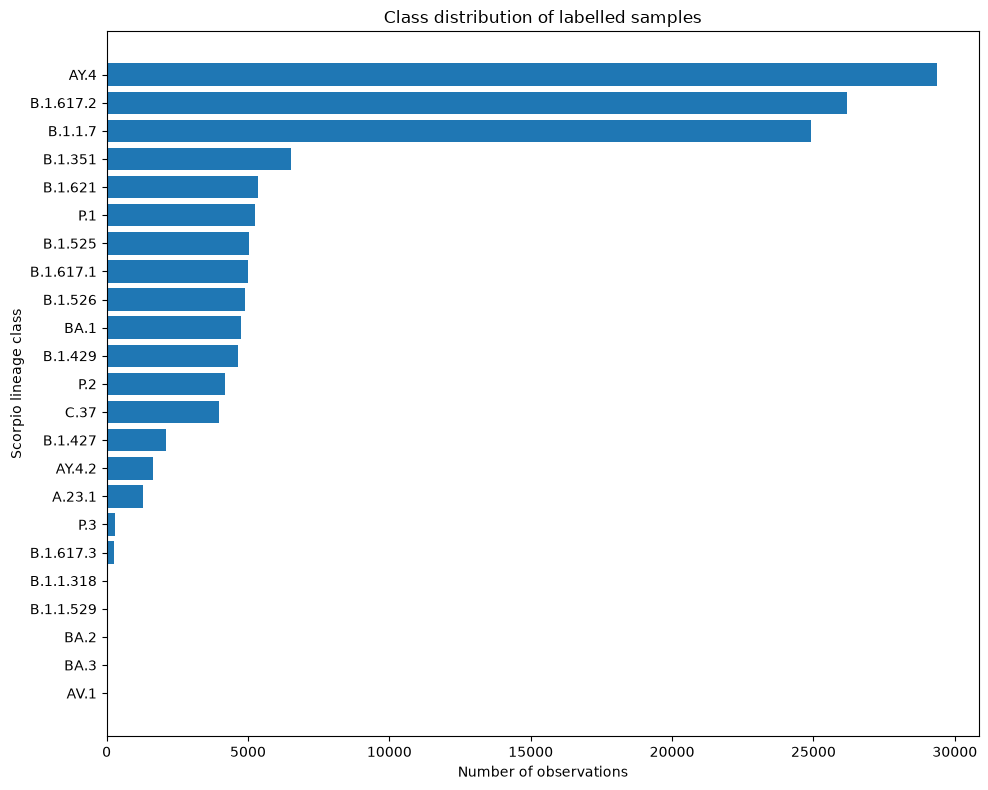

In [6]:
def clean_target_labels(df, target_col=TARGET_COL):
    """Remove missing or undefined target labels."""
    out = df.copy()
    out[target_col] = out[target_col].astype(str).str.strip()
    invalid = out[target_col].isin(["", "None", "none", "nan", "NaN", "NA", "N/A"])
    out["valid_target"] = ~invalid
    return out


def class_distribution_table(metadata, target_col=TARGET_COL):
    counts = metadata[target_col].value_counts(dropna=False).rename_axis("class_label").reset_index(name="n_observations")
    counts["proportion"] = counts["n_observations"] / counts["n_observations"].sum()
    return counts.sort_values(["n_observations", "class_label"], ascending=[False, True]).reset_index(drop=True)


class_counts_all_valid = class_distribution_table(valid_master_metadata)
class_counts_all_valid.to_csv(METRICS_DIR / "class_distribution_all_valid_labels.csv", index=False)

display(class_counts_all_valid)
print("Number of valid labelled samples:", len(valid_master_metadata))
print("Number of classes:", class_counts_all_valid.shape[0])
print("Smallest class size:", int(class_counts_all_valid["n_observations"].min()))


# Plotting functions
def plot_class_distribution(counts_df, save_dir=METRICS_DIR):
    """Plot class distribution as a horizontal bar chart."""
    plot_df = counts_df.sort_values("n_observations", ascending=True).copy()

    plt.figure(figsize=(10, 8))
    plt.barh(plot_df["class_label"], plot_df["n_observations"])
    plt.xlabel("Number of observations")
    plt.ylabel("Scorpio lineage class")
    plt.title("Class distribution of labelled samples")
    plt.tight_layout()
    plt.savefig(save_dir / "class_distribution_barplot.png", dpi=300, bbox_inches="tight")
    plt.show()



plot_class_distribution(class_counts_all_valid)


## 7. Rare-class filtering

This section applies the rare-class rule used for the main analysis. Classes with fewer than 30 observations are excluded before the main modelling workflow so that stratified splitting, repeated stratified cross-validation and class-specific stability estimation remain feasible.

In [7]:
def threshold_diagnostics(class_counts, thresholds=(2, 5, 10, 20, 30, 50, 100)):
    rows = []
    total = class_counts["n_observations"].sum()
    for threshold in thresholds:
        below = class_counts[class_counts["n_observations"] < threshold]
        rows.append({
            "threshold": threshold,
            "classes_below_threshold": below.shape[0],
            "observations_below_threshold": int(below["n_observations"].sum()),
            "proportion_below_threshold": below["n_observations"].sum() / total,
            "classes_retained": class_counts.shape[0] - below.shape[0],
            "observations_retained": int(total - below["n_observations"].sum()),
        })
    return pd.DataFrame(rows)


def apply_rare_class_rule(metadata, class_counts, strategy=RARE_CLASS_STRATEGY, min_class_size=MIN_CLASS_SIZE_MAIN):
    """Apply the rare-class rule for the main analysis."""
    if strategy == "retain_all":
        retained_classes = class_counts["class_label"].tolist()
        affected_classes = []
    elif strategy == "exclude_below_threshold":
        retained_classes = class_counts.loc[class_counts["n_observations"] >= min_class_size, "class_label"].tolist()
        affected_classes = class_counts.loc[class_counts["n_observations"] < min_class_size, "class_label"].tolist()
    else:
        raise ValueError(f"Unknown rare-class strategy: {strategy}")

    analysis_metadata = metadata[metadata[TARGET_COL].isin(retained_classes)].copy()
    rare_rule_summary = pd.DataFrame([{
        "strategy": strategy,
        "min_class_size": min_class_size if strategy == "exclude_below_threshold" else np.nan,
        "classes_before": class_counts.shape[0],
        "classes_after": len(retained_classes),
        "observations_before": len(metadata),
        "observations_after": len(analysis_metadata),
        "observations_removed": len(metadata) - len(analysis_metadata),
        "affected_classes": "; ".join(affected_classes),
    }])
    return analysis_metadata, rare_rule_summary


rare_threshold_table = threshold_diagnostics(class_counts_all_valid)
rare_threshold_table.to_csv(METRICS_DIR / "rare_class_threshold_diagnostics.csv", index=False)
display(rare_threshold_table)

analysis_metadata, rare_rule_summary = apply_rare_class_rule(valid_master_metadata, class_counts_all_valid)
rare_rule_summary.to_csv(METRICS_DIR / "rare_class_rule_main_analysis.csv", index=False)
display(rare_rule_summary)

class_counts_main = class_distribution_table(analysis_metadata)
class_counts_main.to_csv(METRICS_DIR / "class_distribution_main_analysis.csv", index=False)
display(class_counts_main)


,threshold,classes_below_threshold,observations_below_threshold,proportion_below_threshold,classes_retained,observations_retained
0,2,1,1,0.000007,22,135779
1,5,1,1,0.000007,22,135779
2,10,3,14,0.000103,20,135766
3,20,4,28,0.000206,19,135752
4,30,4,28,0.000206,19,135752
5,50,5,60,0.000442,18,135720
6,100,5,60,0.000442,18,135720


,strategy,min_class_size,classes_before,classes_after,observations_before,observations_after,observations_removed,affected_classes
0,exclude_below_threshold,30,23,19,135780,135752,28,B.1.1.529; BA.2; BA.3; AV.1


,class_label,n_observations,proportion
0,AY.4,29386,0.216468
1,B.1.617.2,26191,0.192933
2,B.1.1.7,24923,0.183592
3,B.1.351,6527,0.048080
4,B.1.621,5352,0.039425
5,P.1,5247,0.038651
6,B.1.525,5024,0.037009
7,B.1.617.1,5012,0.036920
8,B.1.526,4885,0.035985
9,BA.1,4768,0.035123


## 8. Load aligned feature datasets

This section loads the predictor matrices for each feature representation using the final main-analysis sample set. Rows are aligned using the `taxon` identifier so that all feature representations contain the same samples in the same order.

Only verified predictor columns are loaded. Identifier, target and metadata columns are excluded from the predictor matrices.

In [8]:
def load_feature_matrix_for_ids(rep, path, ordered_ids, target_col=TARGET_COL, id_col=ID_COL):
    """Load one feature representation aligned to ordered sample IDs."""
    cols = read_header(path)
    feature_cols, _ = get_feature_columns_from_header(cols)
    required_cols = [id_col, target_col] + feature_cols
    required_cols = [c for c in required_cols if c in cols]

    df = read_table(path, usecols=required_cols)
    df = df.drop_duplicates(id_col, keep="first")
    df = df[df[id_col].isin(ordered_ids)].copy()

    # Align row order to ordered_ids
    df[id_col] = pd.Categorical(df[id_col], categories=ordered_ids, ordered=True)
    df = df.sort_values(id_col).reset_index(drop=True)
    df[id_col] = df[id_col].astype(str)

    if len(df) != len(ordered_ids):
        missing = set(ordered_ids) - set(df[id_col])
        raise ValueError(f"{rep}: missing {len(missing)} expected IDs after alignment.")

    X = df[feature_cols].apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan).astype("float32")
    y = df[target_col].astype(str).values

    summary = {
        "feature_representation": rep,
        "n_samples": X.shape[0],
        "n_predictors_before_pipeline": X.shape[1],
        "missing_values": int(X.isna().sum().sum()),
        "infinite_values_after_cleaning": int(np.isinf(X.to_numpy(dtype="float32", copy=True)).sum()),
        "target_mismatches_with_master": None,
    }
    return X, y, summary


def load_all_representations_for_analysis(feature_files, analysis_metadata):
    """Load all representations for the main analysis sample set."""
    ordered_ids = analysis_metadata[ID_COL].astype(str).tolist()
    y_master = analysis_metadata[TARGET_COL].astype(str).values
    data = {}
    rows = []

    for rep, path in feature_files.items():
        print(f"Loading {rep}...")
        X, y, summary = load_feature_matrix_for_ids(rep, path, ordered_ids)
        target_mismatches = int(np.sum(y != y_master))
        summary["target_mismatches_with_master"] = target_mismatches
        if target_mismatches > 0:
            raise ValueError(f"{rep}: target labels do not match master metadata for {target_mismatches} samples.")
        data[rep] = {"X": X, "y": y_master, "ids": np.array(ordered_ids)}
        rows.append(summary)

    prep_summary = pd.DataFrame(rows).sort_values("feature_representation")
    prep_summary.to_csv(METRICS_DIR / "prepared_feature_datasets_summary.csv", index=False)
    return data, prep_summary


# Load all main-analysis feature datasets.
# This can use memory because some feature representations are high-dimensional.
prepared_features, prepared_feature_summary = load_all_representations_for_analysis(FEATURE_FILES, analysis_metadata)
display(prepared_feature_summary)

if QUICK_TEST_MODE:
    print("QUICK_TEST_MODE is on: reducing rows for code testing only. Do not use quick-test outputs as final results.")
    keep = np.arange(min(QUICK_TEST_MAX_ROWS, len(analysis_metadata)))
    analysis_metadata = analysis_metadata.iloc[keep].reset_index(drop=True)
    for rep in prepared_features:
        prepared_features[rep]["X"] = prepared_features[rep]["X"].iloc[keep].reset_index(drop=True)
        prepared_features[rep]["y"] = prepared_features[rep]["y"][keep]
        prepared_features[rep]["ids"] = prepared_features[rep]["ids"][keep]


Loading NV...
Loading ANV...
Loading WMRV...
Loading KMNV...


/var/folders/rd/r8qb7cwd2cb5kc9f78fx4rs80000gn/T/ipykernel_10428/3538774967.py:65: DtypeWarning: Columns (0: n_00) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, usecols=usecols)


Loading ENV...


/var/folders/rd/r8qb7cwd2cb5kc9f78fx4rs80000gn/T/ipykernel_10428/3538774967.py:65: DtypeWarning: Columns (0: n_0) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, usecols=usecols)


Loading KMC...


/var/folders/rd/r8qb7cwd2cb5kc9f78fx4rs80000gn/T/ipykernel_10428/3538774967.py:65: DtypeWarning: Columns (0: AAA) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, usecols=usecols)


,feature_representation,n_samples,n_predictors_before_pipeline,missing_values,infinite_values_after_cleaning,target_mismatches_with_master
1,ANV,135752,18,0,0,0
4,ENV,135752,1536,0,0,0
5,KMC,135752,64,0,0,0
3,KMNV,135752,192,0,0,0
0,NV,135752,12,0,0,0
2,WMRV,135752,18,0,0,0


## 9. Development and test split

This section creates one fixed development/test split. The development set is used for feature representation screening, classifier comparison and model selection. The test set is kept separate and is used only after those decisions have been completed.

In [9]:
# All representations have the same aligned rows, so the split can be created once using the labels.
reference_rep = sorted(prepared_features.keys())[0]
y_all = prepared_features[reference_rep]["y"]
indices_all = np.arange(len(y_all))

train_dev_idx, test_idx = train_test_split(
    indices_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

# Stratification preserves class proportions as closely as possible in the development and test sets.

split_summary = pd.DataFrame([{
    "n_total": len(indices_all),
    "n_development": len(train_dev_idx),
    "n_test": len(test_idx),
    "test_size": TEST_SIZE,
    "n_classes": len(np.unique(y_all)),
    "random_state": RANDOM_STATE,
}])
split_summary.to_csv(METRICS_DIR / "development_test_split_summary.csv", index=False)
display(split_summary)

# Save IDs in each split for reproducibility.
pd.DataFrame({"taxon": prepared_features[reference_rep]["ids"][train_dev_idx], "split": "development"}).to_csv(
    METRICS_DIR / "development_ids.csv", index=False
)
pd.DataFrame({"taxon": prepared_features[reference_rep]["ids"][test_idx], "split": "test"}).to_csv(
    METRICS_DIR / "test_ids.csv", index=False
)


,n_total,n_development,n_test,test_size,n_classes,random_state
0,135752,108601,27151,0.2,19,42


## 9.1 Development/test class-distribution checks

This section checks whether the stratified split preserved the target-label distribution across the development and test sets. The outputs are saved to support reproducibility.

,class_label,n_total,n_development,n_test,prop_total,prop_development,prop_test,abs_prop_difference_dev_test
0,AY.4,29386,23509,5877,0.216468,0.216471,0.216456,1.518741e-05
1,B.1.617.2,26191,20953,5238,0.192933,0.192936,0.192921,1.453728e-05
2,B.1.1.7,24923,19938,4985,0.183592,0.183589,0.183603,1.334418e-05
3,B.1.351,6527,5221,1306,0.048080,0.048075,0.048101,2.629530e-05
4,B.1.621,5352,4281,1071,0.039425,0.039420,0.039446,2.653439e-05
5,P.1,5247,4198,1049,0.038651,0.038655,0.038636,1.948331e-05
6,B.1.525,5024,4019,1005,0.037009,0.037007,0.037015,8.185508e-06
7,B.1.617.1,5012,4010,1002,0.036920,0.036924,0.036905,1.943549e-05
8,B.1.526,4885,3908,977,0.035985,0.035985,0.035984,9.940224e-07
9,BA.1,4768,3814,954,0.035123,0.035119,0.035137,1.744542e-05


,n_classes_total,n_classes_development,n_classes_test,smallest_development_class,smallest_test_class,largest_development_class,largest_test_class,maximum_absolute_proportion_difference
0,19,19,19,26,6,23509,5877,0.000027


All retained classes are present in the development set.
All retained classes are present in the test set.


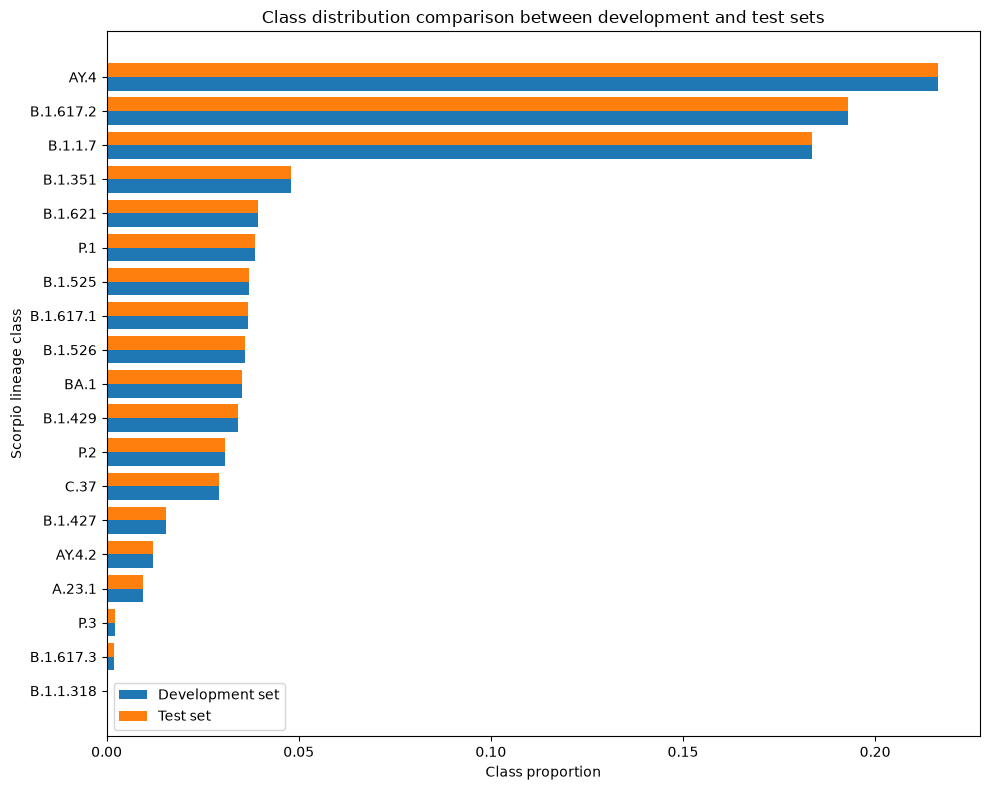

In [10]:
import matplotlib.pyplot as plt

def split_class_distribution(y_all, train_dev_idx, test_idx):
    """
    Compare class distributions in the full dataset, development set and test set.
    """
    y_all = pd.Series(y_all, name=TARGET_COL)
    y_dev = pd.Series(y_all.iloc[train_dev_idx].values, name=TARGET_COL)
    y_test = pd.Series(y_all.iloc[test_idx].values, name=TARGET_COL)

    full_counts = y_all.value_counts().rename_axis("class_label").reset_index(name="n_total")
    dev_counts = y_dev.value_counts().rename_axis("class_label").reset_index(name="n_development")
    test_counts = y_test.value_counts().rename_axis("class_label").reset_index(name="n_test")

    summary = (
        full_counts
        .merge(dev_counts, on="class_label", how="left")
        .merge(test_counts, on="class_label", how="left")
    )

    summary[["n_development", "n_test"]] = summary[["n_development", "n_test"]].fillna(0).astype(int)

    summary["prop_total"] = summary["n_total"] / summary["n_total"].sum()
    summary["prop_development"] = summary["n_development"] / summary["n_development"].sum()
    summary["prop_test"] = summary["n_test"] / summary["n_test"].sum()

    summary["abs_prop_difference_dev_test"] = (
        summary["prop_development"] - summary["prop_test"]
    ).abs()

    summary = summary.sort_values("n_total", ascending=False).reset_index(drop=True)

    return summary


split_class_summary = split_class_distribution(y_all, train_dev_idx, test_idx)

split_class_summary.to_csv(
    METRICS_DIR / "class_distribution_development_test_split.csv",
    index=False
)

display(split_class_summary)

split_distribution_checks = pd.DataFrame([{
    "n_classes_total": split_class_summary.shape[0],
    "n_classes_development": int((split_class_summary["n_development"] > 0).sum()),
    "n_classes_test": int((split_class_summary["n_test"] > 0).sum()),
    "smallest_development_class": int(split_class_summary["n_development"].min()),
    "smallest_test_class": int(split_class_summary["n_test"].min()),
    "largest_development_class": int(split_class_summary["n_development"].max()),
    "largest_test_class": int(split_class_summary["n_test"].max()),
    "maximum_absolute_proportion_difference": float(split_class_summary["abs_prop_difference_dev_test"].max())
}])

split_distribution_checks.to_csv(
    METRICS_DIR / "development_test_class_distribution_checks.csv",
    index=False
)

display(split_distribution_checks)

missing_from_development = split_class_summary.loc[
    split_class_summary["n_development"] == 0, "class_label"
].tolist()

missing_from_test = split_class_summary.loc[
    split_class_summary["n_test"] == 0, "class_label"
].tolist()

if missing_from_development:
    print("Warning: these classes are missing from the development set:")
    print(missing_from_development)
else:
    print("All retained classes are present in the development set.")

if missing_from_test:
    print("Warning: these classes are missing from the test set:")
    print(missing_from_test)
else:
    print("All retained classes are present in the test set.")


# Plot class proportions in development and test sets
plot_df = split_class_summary.sort_values("n_total", ascending=True).copy()

y_positions = np.arange(len(plot_df))
bar_height = 0.4

plt.figure(figsize=(10, 8))
plt.barh(
    y_positions - bar_height / 2,
    plot_df["prop_development"],
    height=bar_height,
    label="Development set"
)
plt.barh(
    y_positions + bar_height / 2,
    plot_df["prop_test"],
    height=bar_height,
    label="Test set"
)

plt.yticks(y_positions, plot_df["class_label"])
plt.xlabel("Class proportion")
plt.ylabel("Scorpio lineage class")
plt.title("Class distribution comparison between development and test sets")
plt.legend()
plt.tight_layout()

plt.savefig(
    METRICS_DIR / "development_test_class_distribution_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Preprocessing pipelines and classifier definitions

This section defines the preprocessing pipelines and supervised classifiers evaluated in the analysis. Preprocessing is placed inside scikit-learn pipelines so that it is fitted within each training fold, development fit or bootstrap sample.

In [11]:
def make_preprocessor(scale=False):
    """Create preprocessing steps fitted only within model training."""
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold(threshold=0.0)),
    ]
    if scale:
        steps.append(("scaler", StandardScaler()))
    return Pipeline(steps)


def make_calibrated_linear_svm():
    """Create a calibrated linear SVM with predict_proba support."""
    base = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000)
    try:
        return CalibratedClassifierCV(estimator=base, cv=3, method="sigmoid")
    except TypeError:
        return CalibratedClassifierCV(base_estimator=base, cv=3, method="sigmoid")


def get_model_pipelines():
    """Return the supervised ML model pipelines used in the comparison."""
    return {
        "Decision Tree": Pipeline([
            ("prep", make_preprocessor(scale=False)),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        "Random Forest": Pipeline([
            ("prep", make_preprocessor(scale=False)),
            ("model", RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                class_weight="balanced",
                n_jobs=-1,
            )),
        ]),
        "Gaussian Naive Bayes": Pipeline([
            ("prep", make_preprocessor(scale=False)),
            ("model", GaussianNB()),
        ]),
        "K-Nearest Neighbours": Pipeline([
            ("prep", make_preprocessor(scale=True)),
            ("model", KNeighborsClassifier(n_neighbors=5)),
        ]),
        "Support Vector Machine": Pipeline([
            ("prep", make_preprocessor(scale=True)),
            ("model", make_calibrated_linear_svm()),
        ]),
        "Neural Network": Pipeline([
            ("prep", make_preprocessor(scale=True)),
            ("model", MLPClassifier(
                hidden_layer_sizes=(100,),
                activation="relu",
                solver="adam",
                max_iter=500,
                early_stopping=True,
                random_state=RANDOM_STATE,
            )),
        ]),
        "Logistic Regression": Pipeline([
            ("prep", make_preprocessor(scale=True)),
            ("model", LogisticRegression(
                max_iter=2000,
                solver="lbfgs",
                class_weight="balanced",
            )),
        ]),
    }


MODEL_PIPELINES = get_model_pipelines()
print("Models included:")
for model_name in MODEL_PIPELINES:
    print("-", model_name)


Models included:
- Decision Tree
- Random Forest
- Gaussian Naive Bayes
- K-Nearest Neighbours
- Support Vector Machine
- Neural Network
- Logistic Regression


## 11. Evaluation functions

These functions calculate the classification and probability-based performance metrics used throughout the notebook. They also align predicted probability columns so that probability-based metrics are calculated consistently across models.

In [12]:
def align_probability_columns(model, proba, class_labels):
    """Align predicted probability columns to the full class label order."""
    if proba is None:
        return None

    if hasattr(model, "classes_"):
        model_classes = list(model.classes_)
    elif hasattr(model, "named_steps") and hasattr(model.named_steps.get("model"), "classes_"):
        model_classes = list(model.named_steps["model"].classes_)
    else:
        return proba

    aligned = np.zeros((proba.shape[0], len(class_labels)), dtype="float32")
    class_to_pos = {c: i for i, c in enumerate(class_labels)}
    for j, c in enumerate(model_classes):
        if c in class_to_pos:
            aligned[:, class_to_pos[c]] = proba[:, j]
    return aligned


def predict_proba_aligned(model, X, class_labels):
    """Return aligned probabilities if supported."""
    if not hasattr(model, "predict_proba"):
        return None
    try:
        proba = model.predict_proba(X)
        return align_probability_columns(model, proba, class_labels)
    except Exception:
        return None


def multiclass_brier_score(y_true, proba, class_labels):
    """Calculate a multiclass Brier score using one-hot encoded true labels."""
    if proba is None:
        return np.nan
    y_bin = label_binarize(y_true, classes=class_labels)
    if y_bin.shape[1] == 1 and len(class_labels) == 2:
        y_bin = np.hstack([1 - y_bin, y_bin])
    return float(np.mean(np.sum((proba - y_bin) ** 2, axis=1)))


def calculate_metrics(y_true, y_pred, proba=None, class_labels=None):
    """Calculate overall classification and probability metrics."""
    if class_labels is None:
        class_labels = np.unique(y_true)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

    if proba is not None:
        try:
            metrics["log_loss"] = log_loss(y_true, proba, labels=class_labels)
        except Exception:
            metrics["log_loss"] = np.nan
        metrics["brier_score_multiclass"] = multiclass_brier_score(y_true, proba, class_labels)
    else:
        metrics["log_loss"] = np.nan
        metrics["brier_score_multiclass"] = np.nan

    return metrics


def class_specific_metrics(y_true, y_pred, class_labels):
    """Calculate class-specific precision, recall and F1-score."""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_labels,
        zero_division=0,
    )
    return pd.DataFrame({
        "class_label": class_labels,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "support": support,
    })


def plot_confusion_matrix(y_true, y_pred, class_labels, title, output_path):
    cm = confusion_matrix(y_true, y_pred, labels=class_labels)
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(class_labels)))
    ax.set_yticks(np.arange(len(class_labels)))
    ax.set_xticklabels(class_labels, rotation=90)
    ax.set_yticklabels(class_labels)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    return cm


## 12. Cross-validation comparison

This section compares all feature representation and classifier combinations using repeated stratified cross-validation on the development set. The test set is not used during this stage.

In [ ]:
def generate_cv_splits(y_dev, n_splits=CV_N_SPLITS, n_repeats=CV_N_REPEATS, random_state=RANDOM_STATE):
    """Generate repeated stratified cross-validation splits."""
    min_count = pd.Series(y_dev).value_counts().min()
    if min_count < n_splits:
        raise ValueError(
            f"Smallest class has {min_count} observations in development data, "
            f"which is fewer than n_splits={n_splits}. Adjust rare-class rule or CV folds."
        )
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    return list(rskf.split(np.zeros(len(y_dev)), y_dev))


def evaluate_model_cv(model_name, model, X_dev, y_dev, cv_splits, class_labels):
    """Evaluate one model with pre-defined CV splits."""
    rows = []
    failed_fits = 0

    for fold_id, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
        X_train = X_dev.iloc[train_idx]
        X_valid = X_dev.iloc[valid_idx]
        y_train = y_dev[train_idx]
        y_valid = y_dev[valid_idx]

        fold_model = clone(model)
        start_fit = time.time()
        try:
            fold_model.fit(X_train, y_train)
            fit_time = time.time() - start_fit
            start_pred = time.time()
            y_pred = fold_model.predict(X_valid)
            pred_time = time.time() - start_pred
            proba = predict_proba_aligned(fold_model, X_valid, class_labels)
            m = calculate_metrics(y_valid, y_pred, proba, class_labels)
            m.update({
                "model": model_name,
                "fold_id": fold_id,
                "fit_time_seconds": fit_time,
                "prediction_time_seconds": pred_time,
                "fit_status": "success",
                "error_message": "",
            })
            rows.append(m)
        except Exception as e:
            failed_fits += 1
            rows.append({
                "model": model_name,
                "fold_id": fold_id,
                "accuracy": np.nan,
                "balanced_accuracy": np.nan,
                "macro_precision": np.nan,
                "macro_recall": np.nan,
                "macro_f1": np.nan,
                "weighted_f1": np.nan,
                "log_loss": np.nan,
                "brier_score_multiclass": np.nan,
                "fit_time_seconds": np.nan,
                "prediction_time_seconds": np.nan,
                "fit_status": "failed",
                "error_message": str(e),
            })

    return pd.DataFrame(rows), failed_fits


def run_cross_validation_comparison(prepared, dev_idx, output_dir=METRICS_DIR):
    """Run CV for every feature representation and model."""
    class_labels = sorted(np.unique(prepared[reference_rep]["y"]))
    y_dev = prepared[reference_rep]["y"][dev_idx]
    cv_splits = generate_cv_splits(y_dev)

    all_rows = []
    all_fold_rows = []

    for rep, data in prepared.items():
        print("\n" + "=" * 90)
        print(f"Cross-validation for feature representation: {rep}")
        X_dev = data["X"].iloc[dev_idx].reset_index(drop=True)
        y_dev_rep = data["y"][dev_idx]

        if not np.array_equal(y_dev_rep, y_dev):
            raise ValueError(f"{rep}: development labels are not aligned with reference labels.")

        for model_name, model in MODEL_PIPELINES.items():
            print(f"  Model: {model_name}")
            fold_results, failed_fits = evaluate_model_cv(model_name, model, X_dev, y_dev_rep, cv_splits, class_labels)
            fold_results["feature_representation"] = rep
            fold_results["n_predictors"] = X_dev.shape[1]
            all_fold_rows.append(fold_results)

            summary = fold_results.select_dtypes(include=[np.number]).mean(numeric_only=True).to_dict()
            stds = fold_results[["macro_f1", "balanced_accuracy", "log_loss", "brier_score_multiclass"]].std(numeric_only=True)
            summary.update({
                "feature_representation": rep,
                "model": model_name,
                "n_predictors": X_dev.shape[1],
                "n_folds": len(cv_splits),
                "failed_fits": failed_fits,
                "macro_f1_std": stds.get("macro_f1", np.nan),
                "balanced_accuracy_std": stds.get("balanced_accuracy", np.nan),
                "log_loss_std": stds.get("log_loss", np.nan),
                "brier_score_std": stds.get("brier_score_multiclass", np.nan),
            })
            all_rows.append(summary)

    cv_summary = pd.DataFrame(all_rows)
    cv_folds = pd.concat(all_fold_rows, ignore_index=True)

    cv_summary.to_csv(output_dir / "cv_model_comparison_summary.csv", index=False)
    cv_folds.to_csv(output_dir / "cv_model_comparison_fold_results.csv", index=False)
    return cv_summary, cv_folds


cv_summary, cv_fold_results = run_cross_validation_comparison(prepared_features, train_dev_idx)
display(cv_summary.sort_values("macro_f1", ascending=False).head(20))



Cross-validation for feature representation: NV
  Model: Decision Tree
  Model: Random Forest
  Model: Gaussian Naive Bayes
  Model: K-Nearest Neighbours
  Model: Support Vector Machine
  Model: Neural Network
  Model: Logistic Regression

Cross-validation for feature representation: ANV
  Model: Decision Tree
  Model: Random Forest
  Model: Gaussian Naive Bayes
  Model: K-Nearest Neighbours
  Model: Support Vector Machine
  Model: Neural Network
  Model: Logistic Regression

Cross-validation for feature representation: WMRV
  Model: Decision Tree
  Model: Random Forest
  Model: Gaussian Naive Bayes
  Model: K-Nearest Neighbours
  Model: Support Vector Machine
  Model: Neural Network
  Model: Logistic Regression

Cross-validation for feature representation: KMNV
  Model: Decision Tree
  Model: Random Forest
  Model: Gaussian Naive Bayes
  Model: K-Nearest Neighbours
  Model: Support Vector Machine


/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Model: Neural Network
  Model: Logistic Regression

Cross-validation for feature representation: ENV
  Model: Decision Tree
  Model: Random Forest
  Model: Gaussian Naive Bayes


/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/metrics/_classification.py:304: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warni

  Model: K-Nearest Neighbours
  Model: Support Vector Machine


/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.11/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/envs/dissertation/lib/python3.

## 13. Feature representation selection

This section selects three feature representations using development-set cross-validation evidence. The rank-based selection table is saved so that the selection decision is transparent and reproducible.

In [ ]:
def select_feature_representations(cv_summary, n_select=3):
    """Select feature representations using transparent CV-based criteria."""
    # Best model result for each representation.
    best_per_rep = (
        cv_summary.sort_values(["feature_representation", "macro_f1"], ascending=[True, False])
        .groupby("feature_representation", as_index=False)
        .first()
    )

    # Rank useful criteria. Lower rank is better.
    best_per_rep["rank_best_macro_f1"] = best_per_rep["macro_f1"].rank(ascending=False, method="min")
    best_per_rep["rank_best_balanced_accuracy"] = best_per_rep["balanced_accuracy"].rank(ascending=False, method="min")
    best_per_rep["rank_macro_f1_stability"] = best_per_rep["macro_f1_std"].rank(ascending=True, method="min")
    best_per_rep["rank_training_time"] = best_per_rep["fit_time_seconds"].rank(ascending=True, method="min")
    best_per_rep["rank_n_predictors"] = best_per_rep["n_predictors"].rank(ascending=True, method="min")

    rank_cols = [
        "rank_best_macro_f1",
        "rank_best_balanced_accuracy",
        "rank_macro_f1_stability",
        "rank_training_time",
        "rank_n_predictors",
    ]
    best_per_rep["feature_selection_rank_sum"] = best_per_rep[rank_cols].sum(axis=1)
    selected_table = best_per_rep.sort_values(["feature_selection_rank_sum", "rank_best_macro_f1"]).reset_index(drop=True)
    selected_reps = selected_table.head(n_select)["feature_representation"].tolist()

    selected_table.to_csv(METRICS_DIR / "feature_representation_selection_table.csv", index=False)
    pd.DataFrame({"selected_feature_representation": selected_reps}).to_csv(
        METRICS_DIR / "selected_three_feature_representations_revised.csv", index=False
    )
    return selected_reps, selected_table


SELECTED_FEATURE_REPRESENTATIONS, feature_selection_table = select_feature_representations(cv_summary)
print("Selected feature representations:", SELECTED_FEATURE_REPRESENTATIONS)
display(feature_selection_table)


## 14. Classifier selection

This section selects one classifier for the final comparison across the selected feature representations. The decision uses development-set evidence only and requires probability support because the bootstrap stability analysis uses predicted class probabilities.

In [ ]:
def model_supports_proba(model):
    return hasattr(model, "predict_proba") or (
        hasattr(model, "named_steps") and hasattr(model.named_steps.get("model"), "predict_proba")
    )


def select_final_model(cv_summary, selected_reps):
    """Select one model using CV performance across selected feature representations."""
    subset = cv_summary[cv_summary["feature_representation"].isin(selected_reps)].copy()

    model_summary = subset.groupby("model", as_index=False).agg(
        mean_macro_f1=("macro_f1", "mean"),
        sd_macro_f1_across_reps=("macro_f1", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        mean_macro_recall=("macro_recall", "mean"),
        mean_weighted_f1=("weighted_f1", "mean"),
        mean_log_loss=("log_loss", "mean"),
        mean_brier_score=("brier_score_multiclass", "mean"),
        mean_fit_time_seconds=("fit_time_seconds", "mean"),
        total_failed_fits=("failed_fits", "sum"),
    )

    model_summary["probability_supported"] = model_summary["model"].map(lambda m: model_supports_proba(MODEL_PIPELINES[m]))

    model_summary["rank_macro_f1"] = model_summary["mean_macro_f1"].rank(ascending=False, method="min")
    model_summary["rank_balanced_accuracy"] = model_summary["mean_balanced_accuracy"].rank(ascending=False, method="min")
    model_summary["rank_macro_f1_consistency"] = model_summary["sd_macro_f1_across_reps"].rank(ascending=True, method="min")
    model_summary["rank_probability_quality"] = model_summary["mean_log_loss"].rank(ascending=True, method="min", na_option="bottom")
    model_summary["rank_training_time"] = model_summary["mean_fit_time_seconds"].rank(ascending=True, method="min")
    model_summary["rank_failed_fits"] = model_summary["total_failed_fits"].rank(ascending=True, method="min")

    rank_cols = [
        "rank_macro_f1",
        "rank_balanced_accuracy",
        "rank_macro_f1_consistency",
        "rank_probability_quality",
        "rank_training_time",
        "rank_failed_fits",
    ]
    model_summary["model_selection_rank_sum"] = model_summary[rank_cols].sum(axis=1)

    # Probability support is required for the main stability analysis.
    eligible = model_summary[(model_summary["probability_supported"]) & (model_summary["total_failed_fits"] == 0)].copy()
    if eligible.empty:
        raise ValueError("No probability-compatible model completed all CV fits. Review model settings.")

    selected_row = eligible.sort_values(["model_selection_rank_sum", "rank_macro_f1"]).iloc[0]
    selected_model = selected_row["model"]

    model_summary = model_summary.sort_values(["model_selection_rank_sum", "rank_macro_f1"]).reset_index(drop=True)
    model_summary.to_csv(METRICS_DIR / "final_model_selection_table.csv", index=False)
    pd.DataFrame([selected_row]).to_csv(METRICS_DIR / "selected_model_revised.csv", index=False)
    return selected_model, model_summary


SELECTED_MODEL_NAME, model_selection_table = select_final_model(cv_summary, SELECTED_FEATURE_REPRESENTATIONS)
print("Selected model:", SELECTED_MODEL_NAME)
display(model_selection_table)


## 15. Final test set evaluation

After feature representation and classifier selection are completed using the development data, the selected classifier is fitted on the full development set and evaluated on the fixed test set for each selected feature representation.

In [ ]:
def evaluate_selected_model_on_test(prepared, selected_reps, selected_model_name, dev_idx, test_idx):
    """Fit selected model on development data and evaluate on the held-out test set."""
    class_labels = sorted(np.unique(prepared[reference_rep]["y"]))
    rows = []
    class_metric_tables = []

    for rep in selected_reps:
        print("\n" + "=" * 90)
        print(f"Held-out test evaluation: {rep} + {selected_model_name}")
        X = prepared[rep]["X"]
        y = prepared[rep]["y"]

        X_dev = X.iloc[dev_idx]
        y_dev = y[dev_idx]
        X_test = X.iloc[test_idx]
        y_test = y[test_idx]

        model = clone(MODEL_PIPELINES[selected_model_name])
        start_fit = time.time()
        model.fit(X_dev, y_dev)
        fit_time = time.time() - start_fit

        start_pred = time.time()
        y_pred = model.predict(X_test)
        pred_time = time.time() - start_pred
        proba = predict_proba_aligned(model, X_test, class_labels)

        metrics = calculate_metrics(y_test, y_pred, proba, class_labels)
        metrics.update({
            "feature_representation": rep,
            "model": selected_model_name,
            "n_development": len(dev_idx),
            "n_test": len(test_idx),
            "n_predictors": X.shape[1],
            "fit_time_seconds": fit_time,
            "prediction_time_seconds": pred_time,
        })
        rows.append(metrics)

        # Save model, predictions and class-specific metrics.
        safe_model_name = selected_model_name.replace(" ", "_").replace("-", "_")
        dump(model, MODELS_DIR / f"final_{rep}_{safe_model_name}.joblib")

        pred_df = pd.DataFrame({
            ID_COL: prepared[rep]["ids"][test_idx],
            "true_label": y_test,
            "predicted_label": y_pred,
        })
        if proba is not None:
            for j, cls in enumerate(class_labels):
                pred_df[f"proba_{cls}"] = proba[:, j]
        pred_df.to_csv(METRICS_DIR / f"test_predictions_{rep}_{safe_model_name}.csv", index=False)

        cm = plot_confusion_matrix(
            y_test,
            y_pred,
            class_labels,
            title=f"Confusion matrix: {rep} + {selected_model_name}",
            output_path=FIGURES_DIR / f"confusion_matrix_test_{rep}_{safe_model_name}.png",
        )
        pd.DataFrame(cm, index=class_labels, columns=class_labels).to_csv(
            METRICS_DIR / f"confusion_matrix_test_{rep}_{safe_model_name}.csv"
        )

        cls_metrics = class_specific_metrics(y_test, y_pred, class_labels)
        cls_metrics["feature_representation"] = rep
        cls_metrics["model"] = selected_model_name
        cls_metrics.to_csv(METRICS_DIR / f"class_specific_test_metrics_{rep}_{safe_model_name}.csv", index=False)
        class_metric_tables.append(cls_metrics)

    test_summary = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
    test_summary.to_csv(METRICS_DIR / "held_out_test_performance_selected_model.csv", index=False)

    all_class_metrics = pd.concat(class_metric_tables, ignore_index=True)
    all_class_metrics.to_csv(METRICS_DIR / "class_specific_test_metrics_selected_model.csv", index=False)
    return test_summary, all_class_metrics


test_performance_summary, class_specific_test_summary = evaluate_selected_model_on_test(
    prepared_features,
    SELECTED_FEATURE_REPRESENTATIONS,
    SELECTED_MODEL_NAME,
    train_dev_idx,
    test_idx,
)

display(test_performance_summary)


## 16. Bootstrap stability configuration

This section defines the bootstrap stability functions. For each selected feature representation, a reference model is fitted using the full development set. Bootstrap models are then fitted on resampled development data and applied to the same fixed test set.

The saved bootstrap predictions are used later to quantify probability instability, classification switching and class-specific stability.

In [ ]:
# Draw a bootstrap sample while preserving the class structure.
def stratified_bootstrap_indices(y, random_state=None):
    """Draw a stratified bootstrap sample with replacement from y."""
    rng = check_random_state(random_state)
    y = np.asarray(y)
    sampled_indices = []
    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]
        sampled = rng.choice(cls_idx, size=len(cls_idx), replace=True)
        sampled_indices.append(sampled)
    return np.concatenate(sampled_indices)

# Draw an ordinary bootstrap sample without using class labels.
def ordinary_bootstrap_indices(n, random_state=None):
    rng = check_random_state(random_state)
    return rng.choice(np.arange(n), size=n, replace=True)

# Convert text labels into numerical codes.
def encode_labels_to_codes(labels, class_labels):
    mapping = {c: i for i, c in enumerate(class_labels)}
    return np.array([mapping[x] for x in labels], dtype="int16")


# Convert numerical codes back to class labels.
def decode_codes_to_labels(codes, class_labels):
    class_labels = np.array(class_labels)
    return class_labels[np.asarray(codes)]

# Run bootstrap stability analysis for one feature representation at a time.

def run_bootstrap_stability_for_representation(rep, prepared, selected_model_name, dev_idx, test_idx, b_bootstrap=B_BOOTSTRAP):
    """Run or resume bootstrap stability analysis for one feature representation."""
    safe_model_name = selected_model_name.replace(" ", "_").replace("-", "_")
    # This creates a separate folder for each feature representation and model.
    run_dir = BOOTSTRAP_DIR / f"{rep}_{safe_model_name}_B{b_bootstrap}"
    run_dir.mkdir(parents=True, exist_ok=True)

    X = prepared[rep]["X"]
    y = prepared[rep]["y"]
    ids = prepared[rep]["ids"]
    class_labels = sorted(np.unique(y))

    X_dev = X.iloc[dev_idx]
    y_dev = y[dev_idx]
    X_test = X.iloc[test_idx]
    y_test = y[test_idx]
    test_ids = ids[test_idx]

    # Reference model fitted once to the complete development dataset.
    reference_model_path = run_dir / "reference_model.joblib"
    reference_predictions_path = run_dir / "reference_predictions.csv"
    reference_proba_path = run_dir / "reference_probabilities.npy"

    if reference_model_path.exists() and reference_predictions_path.exists() and reference_proba_path.exists():
        print(f"Loading existing reference model for {rep}")
        reference_model = load(reference_model_path)
        reference_df = pd.read_csv(reference_predictions_path)
        reference_proba = np.load(reference_proba_path)
    else:
        print(f"Fitting reference model for {rep}")
        reference_model = clone(MODEL_PIPELINES[selected_model_name])
        reference_model.fit(X_dev, y_dev)
        
        # reference model = original model trained on all development data
        # bootstrap models = models trained on resampled versions of development data
        
        ref_pred = reference_model.predict(X_test)
        reference_proba = predict_proba_aligned(reference_model, X_test, class_labels)
        if reference_proba is None:
            raise ValueError(f"{selected_model_name} does not provide probabilities required for stability analysis.")

        reference_df = pd.DataFrame({
            ID_COL: test_ids,
            "true_label": y_test,
            "reference_predicted_label": ref_pred,
        })
        reference_df.to_csv(reference_predictions_path, index=False)
        np.save(reference_proba_path, reference_proba.astype("float32"))
        dump(reference_model, reference_model_path)

    # Bootstrap repetitions. Each repetition is saved separately to allow resume.
    progress_rows = []
    for b in tqdm(range(1, b_bootstrap + 1), desc=f"Bootstrap {rep}"):
        out_file = run_dir / f"bootstrap_{b:04d}.npz"
        status_file = run_dir / f"bootstrap_{b:04d}_status.json"
        if out_file.exists() and status_file.exists():
            continue

        start_time = time.time()
        try:
            if USE_STRATIFIED_BOOTSTRAP:
                sample_pos = stratified_bootstrap_indices(y_dev, random_state=RANDOM_STATE + b)
            else:
                sample_pos = ordinary_bootstrap_indices(len(y_dev), random_state=RANDOM_STATE + b)

            boot_model = clone(MODEL_PIPELINES[selected_model_name])
            boot_model.fit(X_dev.iloc[sample_pos], y_dev[sample_pos])
            boot_pred = boot_model.predict(X_test)
            boot_proba = predict_proba_aligned(boot_model, X_test, class_labels)
            if boot_proba is None:
                raise ValueError("Bootstrap model did not return probabilities.")

            np.savez_compressed(
                out_file,
                pred_codes=encode_labels_to_codes(boot_pred, class_labels),
                proba=boot_proba.astype("float32"),
            )
            status = {
                "rep": rep,
                "model": selected_model_name,
                "bootstrap_iteration": b,
                "status": "success",
                "runtime_seconds": time.time() - start_time,
                "error_message": "",
            }
        except Exception as e:
            status = {
                "rep": rep,
                "model": selected_model_name,
                "bootstrap_iteration": b,
                "status": "failed",
                "runtime_seconds": time.time() - start_time,
                "error_message": str(e),
            }
        with open(status_file, "w") as f:
            json.dump(status, f, indent=2)
        progress_rows.append(status)

    # Save a progress file after the run.
    status_records = []
    for p in sorted(run_dir.glob("bootstrap_*_status.json")):
        with open(p) as f:
            status_records.append(json.load(f))
    status_df = pd.DataFrame(status_records)
    status_df.to_csv(run_dir / "bootstrap_status_summary.csv", index=False)
    print(status_df["status"].value_counts(dropna=False))
    return run_dir


## 17. Bootstrap stability execution

This section runs or resumes the bootstrap stability analysis for each selected feature representation. Each bootstrap repetition is saved separately, which allows the analysis to resume if it is interrupted.

In [ ]:
bootstrap_run_dirs = {}
for rep in SELECTED_FEATURE_REPRESENTATIONS:
    run_dir = run_bootstrap_stability_for_representation(
        rep,
        prepared_features,
        SELECTED_MODEL_NAME,
        train_dev_idx,
        test_idx,
        b_bootstrap=B_BOOTSTRAP,
    )
    bootstrap_run_dirs[rep] = run_dir

with open(BOOTSTRAP_DIR / "bootstrap_run_directories.json", "w") as f:
    json.dump({rep: str(path) for rep, path in bootstrap_run_dirs.items()}, f, indent=2)


## 18. Bootstrap stability summaries

This section loads the saved bootstrap outputs and calculates the main prediction stability metrics. These include mean absolute probability change, probability interval width, classification switching rate and prediction agreement rate.

In [ ]:
def load_bootstrap_outputs(run_dir, class_labels):
    """Load saved bootstrap outputs from a run directory."""
    files = sorted(Path(run_dir).glob("bootstrap_*.npz"))
    pred_list = []
    proba_list = []
    successful_iterations = []

    for f in files:
        arr = np.load(f)
        pred_list.append(arr["pred_codes"].astype("int16"))
        proba_list.append(arr["proba"].astype("float32"))
        successful_iterations.append(int(f.stem.split("_")[1]))

    if not pred_list:
        raise ValueError(f"No successful bootstrap outputs found in {run_dir}")

    pred_codes = np.stack(pred_list, axis=0)  # B x n_test
    probabilities = np.stack(proba_list, axis=0)  # B x n_test x n_classes
    return pred_codes, probabilities, successful_iterations


def summarise_bootstrap_stability(rep, run_dir, selected_model_name):
    """Summarise bootstrap prediction stability for one representation."""
    class_labels = sorted(np.unique(prepared_features[reference_rep]["y"]))
    reference_df = pd.read_csv(Path(run_dir) / "reference_predictions.csv")
    reference_proba = np.load(Path(run_dir) / "reference_probabilities.npy").astype("float32")

    y_test = reference_df["true_label"].astype(str).values
    ref_pred = reference_df["reference_predicted_label"].astype(str).values
    ref_pred_codes = encode_labels_to_codes(ref_pred, class_labels)

    boot_pred_codes, boot_probabilities, successful_iterations = load_bootstrap_outputs(run_dir, class_labels)
    n_boot, n_test, n_classes = boot_probabilities.shape

    # Probability stability over all classes.
    abs_prob_change_all = np.abs(boot_probabilities - reference_proba[None, :, :])
    mean_abs_prob_change_all_classes = float(abs_prob_change_all.mean())

    # Probability stability for the reference predicted class of each observation.
    row_idx = np.arange(n_test)
    ref_class_proba = reference_proba[row_idx, ref_pred_codes]
    boot_ref_class_proba = boot_probabilities[:, row_idx, ref_pred_codes]
    abs_prob_change_ref_class = np.abs(boot_ref_class_proba - ref_class_proba[None, :])

    individual_mean_abs_prob_change = abs_prob_change_ref_class.mean(axis=0)
    individual_prob_sd = boot_ref_class_proba.std(axis=0)
    interval_lower = np.percentile(boot_ref_class_proba, 2.5, axis=0)
    interval_upper = np.percentile(boot_ref_class_proba, 97.5, axis=0)
    individual_interval_width = interval_upper - interval_lower

    # Classification stability compared with the reference model.
    switched = boot_pred_codes != ref_pred_codes[None, :]
    individual_switching_rate = switched.mean(axis=0)
    overall_switching_rate = float(individual_switching_rate.mean())
    prediction_agreement_rate = 1.0 - overall_switching_rate

    summary = pd.DataFrame([{
        "feature_representation": rep,
        "model": selected_model_name,
        "requested_bootstrap_repetitions": B_BOOTSTRAP,
        "successful_bootstrap_repetitions": n_boot,
        "n_test_observations": n_test,
        "mean_absolute_probability_change_all_classes": mean_abs_prob_change_all_classes,
        "mean_absolute_probability_change_reference_class": float(individual_mean_abs_prob_change.mean()),
        "mean_probability_sd_reference_class": float(individual_prob_sd.mean()),
        "mean_95_probability_interval_width_reference_class": float(individual_interval_width.mean()),
        "classification_switching_rate": overall_switching_rate,
        "prediction_agreement_rate": prediction_agreement_rate,
    }])

    individual = pd.DataFrame({
        ID_COL: reference_df[ID_COL].values,
        "true_label": y_test,
        "reference_predicted_label": ref_pred,
        "reference_predicted_probability": ref_class_proba,
        "mean_absolute_probability_change_reference_class": individual_mean_abs_prob_change,
        "probability_sd_reference_class": individual_prob_sd,
        "probability_interval_width_reference_class": individual_interval_width,
        "classification_switching_rate": individual_switching_rate,
        "prediction_agreement_rate": 1.0 - individual_switching_rate,
    })

    class_specific = individual.groupby("true_label", as_index=False).agg(
        n_test_observations=(ID_COL, "count"),
        mean_abs_probability_change=("mean_absolute_probability_change_reference_class", "mean"),
        mean_probability_sd=("probability_sd_reference_class", "mean"),
        mean_interval_width=("probability_interval_width_reference_class", "mean"),
        mean_classification_switching_rate=("classification_switching_rate", "mean"),
    )

    # Class switching matrix from reference prediction to bootstrap prediction.
    switch_counts = np.zeros((n_classes, n_classes), dtype="float64")
    for b in range(n_boot):
        cm = confusion_matrix(ref_pred_codes, boot_pred_codes[b], labels=np.arange(n_classes))
        switch_counts += cm
    switch_counts = switch_counts / n_boot
    switch_matrix = pd.DataFrame(switch_counts, index=[f"reference_{c}" for c in class_labels], columns=[f"bootstrap_{c}" for c in class_labels])

    safe_model_name = selected_model_name.replace(" ", "_").replace("-", "_")
    summary.to_csv(METRICS_DIR / f"bootstrap_stability_summary_{rep}_{safe_model_name}.csv", index=False)
    individual.to_csv(METRICS_DIR / f"bootstrap_individual_stability_{rep}_{safe_model_name}.csv", index=False)
    class_specific.to_csv(METRICS_DIR / f"bootstrap_class_specific_stability_{rep}_{safe_model_name}.csv", index=False)
    switch_matrix.to_csv(METRICS_DIR / f"bootstrap_class_switching_matrix_{rep}_{safe_model_name}.csv")

    return summary, individual, class_specific, switch_matrix


bootstrap_summary_tables = []
bootstrap_class_tables = []
for rep, run_dir in bootstrap_run_dirs.items():
    summary, individual, class_specific, switch_matrix = summarise_bootstrap_stability(rep, run_dir, SELECTED_MODEL_NAME)
    bootstrap_summary_tables.append(summary)
    bootstrap_class_tables.append(class_specific.assign(feature_representation=rep, model=SELECTED_MODEL_NAME))

bootstrap_overall_summary = pd.concat(bootstrap_summary_tables, ignore_index=True)
bootstrap_overall_summary.to_csv(METRICS_DIR / "bootstrap_stability_summary_all_selected_representations.csv", index=False)

overall_class_stability = pd.concat(bootstrap_class_tables, ignore_index=True)
overall_class_stability.to_csv(METRICS_DIR / "bootstrap_class_specific_stability_all_selected_representations.csv", index=False)

display(bootstrap_overall_summary)


## 19. Performance and stability plots

This section creates summary plots combining final test set performance and bootstrap stability results. The corresponding numerical table is also exported.

In [ ]:
def plot_performance_stability_comparison(test_summary, stability_summary):
    merged = test_summary.merge(
        stability_summary,
        on=["feature_representation", "model"],
        how="left",
    )
    merged.to_csv(METRICS_DIR / "performance_stability_comparison_table.csv", index=False)

    # Macro F1 bar plot.
    plot_df = merged.sort_values("macro_f1", ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(plot_df["feature_representation"], plot_df["macro_f1"])
    ax.set_xlabel("Held-out test macro F1-score")
    ax.set_ylabel("Feature representation")
    ax.set_title(f"Held-out test performance using {SELECTED_MODEL_NAME}")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "selected_model_test_macro_f1_by_feature.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Stability bar plot.
    plot_df = merged.sort_values("classification_switching_rate", ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(plot_df["feature_representation"], plot_df["classification_switching_rate"])
    ax.set_xlabel("Classification switching rate")
    ax.set_ylabel("Feature representation")
    ax.set_title(f"Bootstrap classification instability using {SELECTED_MODEL_NAME}")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "selected_model_classification_instability_by_feature.png", dpi=200, bbox_inches="tight")
    plt.show()

    # Performance vs stability scatter.
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(merged["macro_f1"], merged["classification_switching_rate"])
    for _, row in merged.iterrows():
        ax.annotate(row["feature_representation"], (row["macro_f1"], row["classification_switching_rate"]))
    ax.set_xlabel("Held-out test macro F1-score")
    ax.set_ylabel("Classification switching rate")
    ax.set_title("Performance and stability comparison")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "performance_vs_classification_instability.png", dpi=200, bbox_inches="tight")
    plt.show()

    return merged


performance_stability_table = plot_performance_stability_comparison(test_performance_summary, bootstrap_overall_summary)
display(performance_stability_table)


## 20. Class-specific performance and stability

This section combines class-specific test performance with class-specific bootstrap stability. The purpose is to examine whether instability is concentrated in particular variant classes rather than only reporting average instability.

In [ ]:
def combine_class_performance_and_stability(class_perf, class_stab):
    merged = class_perf.merge(
        class_stab,
        left_on=["feature_representation", "model", "class_label"],
        right_on=["feature_representation", "model", "true_label"],
        how="left",
    )
    merged = merged.drop(columns=["true_label"], errors="ignore")
    merged.to_csv(METRICS_DIR / "class_specific_performance_and_stability.csv", index=False)
    return merged


class_performance_stability = combine_class_performance_and_stability(class_specific_test_summary, overall_class_stability)
display(class_performance_stability.sort_values("mean_classification_switching_rate", ascending=False).head(20))

# Plot class-specific instability for each selected representation.
for rep in SELECTED_FEATURE_REPRESENTATIONS:
    tmp = class_performance_stability[class_performance_stability["feature_representation"] == rep].sort_values(
        "mean_classification_switching_rate", ascending=True
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(tmp["class_label"], tmp["mean_classification_switching_rate"])
    ax.set_xlabel("Mean classification switching rate")
    ax.set_ylabel("True class")
    ax.set_title(f"Class-specific instability: {rep} + {SELECTED_MODEL_NAME}")
    fig.tight_layout()
    safe_model_name = SELECTED_MODEL_NAME.replace(" ", "_").replace("-", "_")
    fig.savefig(FIGURES_DIR / f"class_specific_instability_{rep}_{safe_model_name}.png", dpi=200, bbox_inches="tight")
    plt.show()


## 21. Final performance-stability comparison

This section combines final test set performance and bootstrap stability metrics into one transparent comparison table. The rank summary is used only to support interpretation of the final comparison.

In [ ]:
def create_final_comparison_table(performance_stability_table):
    df = performance_stability_table.copy()
    df["rank_macro_f1"] = df["macro_f1"].rank(ascending=False, method="min")
    df["rank_balanced_accuracy"] = df["balanced_accuracy"].rank(ascending=False, method="min")
    df["rank_log_loss"] = df["log_loss"].rank(ascending=True, method="min", na_option="bottom")
    df["rank_classification_switching_rate"] = df["classification_switching_rate"].rank(ascending=True, method="min")
    df["rank_probability_change"] = df["mean_absolute_probability_change_reference_class"].rank(ascending=True, method="min")
    df["rank_interval_width"] = df["mean_95_probability_interval_width_reference_class"].rank(ascending=True, method="min")

    rank_cols = [
        "rank_macro_f1",
        "rank_balanced_accuracy",
        "rank_log_loss",
        "rank_classification_switching_rate",
        "rank_probability_change",
        "rank_interval_width",
    ]
    df["transparent_rank_sum"] = df[rank_cols].sum(axis=1)
    df = df.sort_values(["transparent_rank_sum", "rank_macro_f1"]).reset_index(drop=True)
    df.to_csv(METRICS_DIR / "final_performance_stability_comparison_ranked.csv", index=False)
    return df


final_comparison_table = create_final_comparison_table(performance_stability_table)
display(final_comparison_table)

print("Important: the selected feature representation should be based on this generated table, not assumed before running the analysis.")


## 22. Exporting outputs and reproducibility information

This section saves a compact reproducibility summary, including the main configuration settings and selected outputs needed to document the analysis.

In [ ]:
reproducibility_info = {
    "analysis_datetime": datetime.now().isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "random_state": RANDOM_STATE,
    "target_column": TARGET_COL,
    "id_column": ID_COL,
    "feature_start_after_column": FEATURE_START_AFTER_COL,
    "test_size": TEST_SIZE,
    "cv_n_splits": CV_N_SPLITS,
    "cv_n_repeats": CV_N_REPEATS,
    "rare_class_strategy": RARE_CLASS_STRATEGY,
    "min_class_size_main": MIN_CLASS_SIZE_MAIN,
    "selected_feature_representations": SELECTED_FEATURE_REPRESENTATIONS,
    "selected_model_name": SELECTED_MODEL_NAME,
    "bootstrap_repetitions_requested": B_BOOTSTRAP,
    "use_stratified_bootstrap": USE_STRATIFIED_BOOTSTRAP,
    "quick_test_mode": QUICK_TEST_MODE,
}

with open(OUTPUT_DIR / "reproducibility_info.json", "w") as f:
    json.dump(reproducibility_info, f, indent=2)

# Save a compact run summary.
run_summary = pd.DataFrame([{
    "selected_model": SELECTED_MODEL_NAME,
    "selected_feature_representations": "; ".join(SELECTED_FEATURE_REPRESENTATIONS),
    "n_main_analysis_samples": len(analysis_metadata),
    "n_main_analysis_classes": class_counts_main.shape[0],
    "n_development": len(train_dev_idx),
    "n_test": len(test_idx),
    "bootstrap_repetitions_requested": B_BOOTSTRAP,
}])
run_summary.to_csv(METRICS_DIR / "run_summary_revised_analysis.csv", index=False)
display(run_summary)

print("Analysis outputs saved in:", OUTPUT_DIR)
